# scMultiSim — CellSTIC tutorial

**Dataset:** scMultiSim replicate `re1`–`re8`. See `data/scmultisim/README.md` for dataset preparation details.


## Step 1 — Setup


In [22]:
import sys
import base64
from pathlib import Path

%load_ext autoreload
%autoreload 2

_cwd = Path.cwd()
project_root = _cwd if (_cwd / "model").is_dir() else _cwd.parent
sys.path.insert(0, str(project_root))

import anndata as ad
import numpy as np
import scanpy as sc
import scipy.sparse as sparse
import torch
from IPython.display import HTML, SVG, display
from scipy.spatial.distance import pdist, squareform

from model.train import CellSTICConfig
from pipeline import run_cellstic
from pipeline.analyzer import SingleLevelAnalysis
from utils.data import SpatialPreprocessorUtils
from utils.metrics import SpatialVisualizer
from utils.tools.seed_utils import set_global_seed

set_global_seed()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


42

## Step 2 — Configuration


In [23]:
cfg = CellSTICConfig()
cfg.model.graph.cluster_top_k = 10
cfg.model.graph.cluster_size = 20
cfg.model.graph.expression_percentile = 50
cfg.model.graph.n_spots = 25
cfg.model.tree.hierarchy_method = "balanced"
cfg.train.ccc.sampling_rate = 0.5
cfg.train.feat.n_clusters = 4
cfg.train.feat.epochs = 500
cfg.train.feat.learning_rate = 0.002
cfg.train.feat.weight_modality = 0.4
cfg.train.feat.entropy_weight = 0.3

RE_NUM = 1

work_dir = project_root / "data" / "scmultisim" / f"re{RE_NUM}"
raw_path = work_dir / "raw"
model_path = work_dir / "model"
result_path = work_dir / "result"
analysis_path = work_dir / "analysis"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Working replicate: re{RE_NUM}")
print(f"Device:           {device}")
print(f"Result path:      {result_path}")
print(f"Analysis path:    {analysis_path}")

Working replicate: re1
Device:           cuda
Result path:      /home/wangshuai/project/CellSTIC/data/scmultisim/re1/result
Analysis path:    /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis


## Step 3 — Load and preprocess

Read `raw/rna.h5ad` and `raw/atac.h5ad`, extract LR / ground-truth metadata from `rna.uns`, and build `obsm['feat']` plus `obsp['spatial_distances']` in memory.


In [24]:
rna, atac = ad.read_h5ad(raw_path / "rna.h5ad"), ad.read_h5ad(raw_path / "atac.h5ad")

labels = rna.uns["ccc_gt"]
lr_map = {
    str(k): [str(x) for x in np.asarray(v).tolist()]
    for k, v in rna.uns["ligand_receptor_map"].items()
}
lr_constraints = {
    str(k): [(int(a), int(b)) for a, b in np.asarray(v).tolist()]
    for k, v in rna.uns["pair_type_constraints"].items()
}

rna.var["mt"] = rna.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(rna, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
sc.pp.filter_genes(rna, min_cells=3)
n_components = min(rna.n_vars, atac.n_vars)
sc.pp.highly_variable_genes(rna, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
rna.obsm["feat"] = SpatialPreprocessorUtils.pca(
    rna[:, rna.var["highly_variable"]], n_comps=n_components
)
SpatialPreprocessorUtils.lsi(atac, use_highly_variable=False, n_components=n_components + 1)
atac.obsm["feat"] = atac.obsm["X_lsi"].copy()
dist = squareform(pdist(rna.obsm["spatial"], metric="euclidean"))
rna.obsp["spatial_distances"] = sparse.csr_matrix(dist)
atac.obsp["spatial_distances"] = sparse.csr_matrix(dist)

print(f"Preprocessed RNA feat {rna.obsm['feat'].shape}, ATAC feat {atac.obsm['feat'].shape}")

Performing LSI analysis...
Preprocessed RNA feat (400, 120), ATAC feat (400, 120)


## Step 4 — Cell-type spatial visualization


Visualizing 400 points with 4 domains in grid style
  Calculated min nearest neighbor distance: 1.0000
  Square size (base * 1.0): 1.2000
  Direct visualization: 400 points, each point gets its own square
Spatial domain visualization (grid style) saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/cell_type_domain/spatial_domain.svg


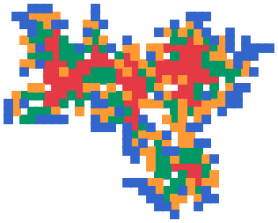

Cell-type spatial distribution saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/cell_type_domain/spatial_domain.svg


In [25]:
rna_viz = rna.copy()
rna_viz.obs["cluster"] = rna_viz.obs["cell_type"].astype(str).astype("category")

save_path_ct = analysis_path / "cell_type_domain" / "spatial_domain.svg"
save_path_ct.parent.mkdir(parents=True, exist_ok=True)
SpatialVisualizer.generate_spatial_domain_visualization(
    adata_source=rna_viz,
    save_path=str(save_path_ct),
    figsize=(4, 3)
)
display(SVG(filename=str(save_path_ct)))
print(f"Cell-type spatial distribution saved to {save_path_ct}")

## Step 5 — Run CellSTIC


In [26]:
result_path.mkdir(parents=True, exist_ok=True)
analysis_path.mkdir(parents=True, exist_ok=True)

# result = run_cellstic(
#     modality_datas=[rna, atac],
#     ligand_receptor_map=lr_map,
#     model_path=model_path,
#     output_path=result_path,
#     config=cfg,
#     device=device,
#     lr_pair_type_constraints=lr_constraints,
# )

# print(f"AnnData saved to {result.adata_path}")

## Step 6 — Initialize downstream analysis

In [27]:
adata = ad.read_h5ad(result_path / "cellstic_result.h5ad")  # skip Step 5; use `adata` below instead of result.adata
analyzer = SingleLevelAnalysis.from_adata(
    adata,
    output_path=analysis_path,
    cell_type_key="cell_type",
    threshold=0.1,
    lr_filter=["101:2", "102:6", "103:10", "104:8", "105:20", "106:30"],
    ccc_ground=labels,
)
print("SingleLevelAnalysis ready.")

SingleLevelAnalysis ready.


## Step 7 — Cell-type communication heatmaps

[SingleLevelAnalysis] run_cell_type_heatmaps


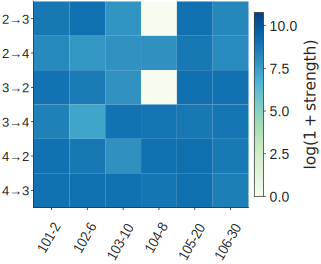

In [28]:
analyzer.run_cell_type_heatmaps(font_size=15)
display(SVG(filename=str(analysis_path / "cell_type_heatmaps/cell_type_pair_lr.svg")))

## Step 8 — Strength vs spatial distance

[SingleLevelAnalysis] run_strength_vs_distance
Strength vs distance plot saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/strength_vs_distance/strength_vs_distance.svg


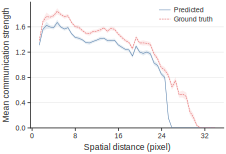

In [29]:
analyzer.run_strength_vs_distance(linewidth=0.5, figsize=(3.2, 2.2))
display(SVG(filename=str(analysis_path / "strength_vs_distance" / "strength_vs_distance.svg")))

## Step 9 — Spatial communication heatmaps

In [30]:
analyzer.run_simple_heatmaps(point_size=50, font_size=18)
paths = sorted((analysis_path / "spatial_heatmaps").glob("*.svg"))
n_cols = (len(paths) + 1) // 2
rows = []
for i in range(0, len(paths), n_cols):
    row_paths = paths[i : i + n_cols]
    cells = []
    for path in row_paths:
        uri = "data:image/svg+xml;base64," + base64.b64encode(path.read_bytes()).decode("ascii")
        cells.append(
            f'<td style="width:{100 / n_cols:.2f}%;padding:4px;text-align:center">'
            f'<img src="{uri}" style="width:100%;max-width:280px;height:auto;"/>'
            f"</td>"
        )
    cells.extend(f'<td style="width:{100 / n_cols:.2f}%"></td>' for _ in range(n_cols - len(row_paths)))
    rows.append("<tr>" + "".join(cells) + "</tr>")
display(HTML(f'<table style="width:100%;table-layout:fixed;border-collapse:collapse"><tbody>{"".join(rows)}</tbody></table>'))

[SingleLevelAnalysis] run_simple_heatmaps
Simple communication heatmap saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/spatial_heatmaps/total.svg
Simple communication heatmap saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/spatial_heatmaps/101_2.svg
Simple communication heatmap saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/spatial_heatmaps/102_6.svg
Simple communication heatmap saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/spatial_heatmaps/103_10.svg
Simple communication heatmap saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/spatial_heatmaps/104_8.svg
Simple communication heatmap saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/spatial_heatmaps/105_20.svg
Simple communication heatmap saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/spatial_heatmaps/106_30.svg


,,,
,,,


## Step 10 — metrics

In [31]:
analyzer.run_roc_pr_metrics()

[SingleLevelAnalysis] run_roc_pr_metrics


=== Summary ===
 macro_f1  macro_accuracy  threshold  macro_auroc  macro_auprc  best_threshold  macro_f1_best  macro_accuracy_best
 0.776197         0.87811        0.1     0.922254     0.693498             0.2       0.758986             0.872183

=== Per LR pair ===
lr_pair       f1  accuracy    auroc    auprc
  101:2 0.817379  0.884593 0.917035 0.694782
  102:6 0.734163  0.853152 0.916815 0.692780
 103:10 0.575418  0.810069 0.915528 0.690502
  104:8 0.790809  0.915746 0.950828 0.696564
 105:20 0.817784  0.884624 0.916653 0.693008
 106:30 0.818365  0.884912 0.916667 0.693350


## Step 11 — Spot-level metrics

[SingleLevelAnalysis] run_spot_level_metrics
Spot-level metrics bar chart saved to /home/wangshuai/project/CellSTIC/data/scmultisim/re1/analysis/spot_level_metrics/spot_level_metrics.svg


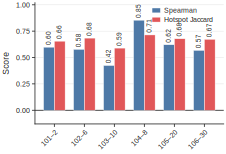

Analysis complete.


In [32]:
analyzer.run_spot_level_metrics(figsize=(3.2, 2.2))
display(SVG(filename=str(analysis_path / "spot_level_metrics" / "spot_level_metrics.svg")))
print("Analysis complete.")